# Global 모델링 Stage 3.5 — Final Hyperparameter Refinement

Stage 3에서 사람이 확정한 25개 Feature와 저장된 Stage 3 결과만 기준선으로 사용한다. Global Train 내부의 SAMPID 5-fold CV에서 Logistic Regression과 XGBoost를 제한적으로 재탐색하고, refined 모델의 Train OOF 확률로 threshold 민감도를 확인한다.

- Test Dataset·Test SAMPID·Test 지표는 읽거나 계산하지 않는다.
- Feature는 `stage_3/selected_features.csv`의 25개를 그대로 사용한다.
- F1 탐색과 OOF 기본 분류 threshold는 0.5로 고정한다.
- 이 Notebook은 모델·threshold를 자동 선택하거나 결과를 연구적으로 해석하지 않는다.

In [1]:
import importlib
import json
import os
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path(os.environ.get('KHUDA_PROJECT_ROOT', Path.cwd())).resolve()
while not (ROOT / 'code').is_dir():
    if ROOT.parent == ROOT:
        raise RuntimeError('KHUDA_PROJECT_ROOT에 저장소 루트를 지정하거나 저장소 안에서 Notebook을 실행하세요.')
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if 'code' in sys.modules and not hasattr(sys.modules['code'], '__path__'):
    del sys.modules['code']
for module_name in ('code.model.final_tuning', 'code.model.tune', 'code.evaluation.threshold'):
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from code.model.final_tuning import (
    boundary_flags, count_grid_combinations, refinement_config, run_lr_refinement,
    run_xgb_refinement_stage_a, run_xgb_refinement_stage_b, run_xgb_refinement_stage_c,
    save_final_tuning_artifacts, stage3_parameter_comparison,
)
from code.model.first_stage import load_stage_fold_f1
from code.model.train import load_model_config
from code.pipeline.saved_results import load_saved_global_train, select_bundle_features
from code.pipeline.run_pipeline import _subset_bundle

EXPERIMENT = 'baseline_42features'
RESULT_ROOT = ROOT / 'data' / 'result' / EXPERIMENT
DATASET_PATH = RESULT_ROOT / 'datasets' / 'local_dataset.parquet'
SPLIT_PATH = RESULT_ROOT / 'splits' / 'split_ids.csv'
STAGE_3_DIR = RESULT_ROOT / 'modeling' / 'stage_3_local_group2' # 여기 바꾸기 25개 피처 결과물 저장했던 폴더랑 경로 같아야함
OUTPUT_DIR = RESULT_ROOT / 'modeling' / 'stage_3_5_local_group2' # 여기 바꾸기
FEATURE_CONFIG = ROOT / 'code' / 'config' / 'features.yaml'
MODEL_CONFIG = ROOT / 'code' / 'config' / 'model_config.yaml'

# GridSearchCV 수준 병렬화만 사용한다. XGBoost 내부 n_jobs=1은 공용 함수가 적용한다.
N_JOBS = -1
PARALLEL_BACKEND = 'threading'
COLORS = {'stage_3': '#7a7a7a', 'stage_3_5': '#0066cc', 'logistic_regression': '#0066cc', 'xgboost': '#333333'}
LABELS = {'logistic_regression': 'Logistic Regression', 'xgboost': 'XGBoost'}
plt.rcParams.update({'figure.facecolor': '#f5f5f7', 'axes.facecolor': '#ffffff', 'axes.edgecolor': '#e0e0e0', 'text.color': '#1d1d1f', 'axes.labelcolor': '#1d1d1f', 'xtick.color': '#1d1d1f', 'ytick.color': '#1d1d1f'})

In [3]:
# Train만 로드한다. load_saved_global_train은 Test DatasetBundle을 만들지 않는다.                     # 이 주석 아래쪽 group명 바꾸기
required_paths = [DATASET_PATH, SPLIT_PATH, STAGE_3_DIR / 'selected_features.csv', STAGE_3_DIR / 'group2_second_stage_summary.csv', STAGE_3_DIR / 'best_params.json', STAGE_3_DIR / 'fold_f1.json', FEATURE_CONFIG, MODEL_CONFIG]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError('필요한 Stage 3.5 입력 파일이 없습니다:\n' + '\n'.join(missing_paths))

train_bundle = load_saved_global_train(DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG)
target_group = '연구·공학·산업기술' # 여기 직군별 수정
train_bundle = _subset_bundle(train_bundle, train_bundle.metadata['job_group'] == target_group)
selected_features = pd.read_csv(STAGE_3_DIR / 'selected_features.csv')['feature'].tolist()
if len(selected_features) != 25 or len(set(selected_features)) != 25:
    raise ValueError('Stage 3 selected_features.csv는 중복 없는 25개 Feature여야 합니다.')
train_bundle = select_bundle_features(train_bundle, selected_features, name='global_stage_3_5_train')
stage3_summary = pd.read_csv(STAGE_3_DIR / 'group2_second_stage_summary.csv') # 여기도 그룹명 바꾸기
stage3_params = json.loads((STAGE_3_DIR / 'best_params.json').read_text(encoding='utf-8'))
stage3_fold_f1 = load_stage_fold_f1(STAGE_3_DIR)
config = load_model_config(MODEL_CONFIG)
refinement = refinement_config(MODEL_CONFIG)

preflight = pd.DataFrame([{
    'train_rows': len(train_bundle.X),
    'train_unique_SAMPID': train_bundle.groups.nunique(),
    'selected_feature_count': len(selected_features),
    'test_used': False,
    'cv_splitter': f"StratifiedGroupKFold(n_splits={config['split']['cv_n_splits']}, shuffle={config['split']['shuffle']}, random_state={config['split']['random_state']})",
    'group_column': 'SAMPID',
    'scoring': config['tuning']['scoring'],
    'threshold': config['tuning']['threshold'],
    'lr_combinations': count_grid_combinations(refinement['logistic_regression']),
    'lr_expected_cv_fits': count_grid_combinations(refinement['logistic_regression']) * 5,
    'xgb_stage_a_combinations': count_grid_combinations(refinement['xgboost']['stage_a']),
    'xgb_stage_a_expected_cv_fits': count_grid_combinations(refinement['xgboost']['stage_a']) * 5,
    'xgb_stage_b_combinations': count_grid_combinations(refinement['xgboost']['stage_b']),
    'xgb_stage_b_expected_cv_fits': count_grid_combinations(refinement['xgboost']['stage_b']) * 5,
    'xgb_stage_c_combinations': count_grid_combinations(refinement['xgboost']['stage_c']),
    'xgb_stage_c_expected_cv_fits': count_grid_combinations(refinement['xgboost']['stage_c']) * 5,
    'total_core_cv_fits': 725,
}])
display(preflight)
if preflight.loc[0, 'lr_expected_cv_fits'] != 140 or preflight.loc[0, 'xgb_stage_a_expected_cv_fits'] != 405 or preflight.loc[0, 'xgb_stage_b_expected_cv_fits'] != 135 or preflight.loc[0, 'xgb_stage_c_expected_cv_fits'] != 45:
    raise ValueError('Stage 3.5 GridSearch 조합 수가 요청한 725 CV fits와 다릅니다.')

display(stage3_parameter_comparison(stage3_params))
display(pd.DataFrame({'feature_order': range(1, 26), 'feature': selected_features}))

,train_rows,train_unique_SAMPID,selected_feature_count,test_used,cv_splitter,group_column,scoring,threshold,lr_combinations,lr_expected_cv_fits,xgb_stage_a_combinations,xgb_stage_a_expected_cv_fits,xgb_stage_b_combinations,xgb_stage_b_expected_cv_fits,xgb_stage_c_combinations,xgb_stage_c_expected_cv_fits,total_core_cv_fits
0,844,554,25,False,"StratifiedGroupKFold(n_splits=5, shuffle=True,...",SAMPID,f1,0.5,28,140,81,405,27,135,9,45,725


,model,expected_params,saved_stage_3_params,matches_request
0,logistic_regression,"{'C': 0.1, 'penalty': 'l2', 'class_weight': 'b...","{'C': 0.01, 'class_weight': 'balanced', 'penal...",False
1,xgboost,"{'max_depth': 3, 'learning_rate': 0.03, 'n_est...","{'colsample_bytree': 0.8, 'learning_rate': 0.0...",False


,feature_order,feature
0,1,gender
1,2,age
2,3,region_5
3,4,baseline_year
4,5,education_level
5,6,student_status
6,7,student_type
7,8,university_type
8,9,major_group
9,10,months_since_graduation


In [8]:
# 제한 refinement를 정확히 한 번 실행한다. Stage A/B/C 경계값이 선택되어도 탐색 범위를 확장하지 않는다.
started_at = time.perf_counter()
lr_refinement = run_lr_refinement(train_bundle, feature_config=FEATURE_CONFIG, model_config=MODEL_CONFIG, parallel_backend_name=PARALLEL_BACKEND, n_jobs=N_JOBS)
xgb_stage_a = run_xgb_refinement_stage_a(train_bundle, stage3_params=stage3_params['xgboost'], feature_config=FEATURE_CONFIG, model_config=MODEL_CONFIG, parallel_backend_name=PARALLEL_BACKEND, n_jobs=N_JOBS)
xgb_stage_b = run_xgb_refinement_stage_b(train_bundle, stage_a_params=xgb_stage_a.best_params, feature_config=FEATURE_CONFIG, model_config=MODEL_CONFIG, parallel_backend_name=PARALLEL_BACKEND, n_jobs=N_JOBS)
xgb_refinement = run_xgb_refinement_stage_c(train_bundle, stage_b_params=xgb_stage_b.best_params, feature_config=FEATURE_CONFIG, model_config=MODEL_CONFIG, parallel_backend_name=PARALLEL_BACKEND, n_jobs=N_JOBS)
elapsed_seconds = time.perf_counter() - started_at

boundary_table = pd.DataFrame([
    {'model': 'logistic_regression', 'refinement_step': 'LR', 'boundary_flags': boundary_flags(lr_refinement.model_result.best_params, refinement['logistic_regression'])},
    {'model': 'xgboost', 'refinement_step': 'Stage A', 'boundary_flags': boundary_flags(xgb_stage_a.best_params, refinement['xgboost']['stage_a'])},
    {'model': 'xgboost', 'refinement_step': 'Stage B', 'boundary_flags': boundary_flags(xgb_stage_b.best_params, refinement['xgboost']['stage_b'])},
    {'model': 'xgboost', 'refinement_step': 'Stage C', 'boundary_flags': boundary_flags(xgb_refinement.model_result.best_params, refinement['xgboost']['stage_c'])},
])
display(pd.DataFrame([
    {'model': 'logistic_regression', 'best_params': lr_refinement.model_result.best_params, 'best_cv_f1': lr_refinement.model_result.best_cv_f1},
    {'model': 'xgboost_stage_a', 'best_params': xgb_stage_a.best_params, 'best_cv_f1': xgb_stage_a.best_cv_f1},
    {'model': 'xgboost_stage_b', 'best_params': xgb_stage_b.best_params, 'best_cv_f1': xgb_stage_b.best_cv_f1},
    {'model': 'xgboost_stage_c', 'best_params': xgb_refinement.model_result.best_params, 'best_cv_f1': xgb_refinement.model_result.best_cv_f1},
]))
display(boundary_table)
print(f'Core CV fits: 725; total elapsed time: {elapsed_seconds / 60:.1f} minutes')

c:\Users\didwo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\didwo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\didwo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,model,best_params,best_cv_f1
0,logistic_regression,"{'C': 0.1, 'class_weight': 'balanced', 'penalt...",0.512309
1,xgboost_stage_a,"{'subsample': 1.0, 'colsample_bytree': 1.0, 's...",0.507684
2,xgboost_stage_b,"{'subsample': 1.0, 'colsample_bytree': 0.8, 's...",0.513039
3,xgboost_stage_c,"{'subsample': 1.0, 'colsample_bytree': 0.8, 's...",0.513039


,model,refinement_step,boundary_flags
0,logistic_regression,LR,"{'C': False, 'penalty': True, 'class_weight': ..."
1,xgboost,Stage A,"{'learning_rate': True, 'n_estimators': True, ..."
2,xgboost,Stage B,"{'subsample': True, 'colsample_bytree': False,..."
3,xgboost,Stage C,"{'reg_alpha': True, 'reg_lambda': True}"


Core CV fits: 725; total elapsed time: 5.3 minutes


In [9]:
# Stage 3 산출물은 읽기만 하고, Stage 3.5 전용 경로에 모든 결과를 새로 저장한다.
artifact_paths = save_final_tuning_artifacts(
    output_dir=OUTPUT_DIR, stage3_summary=stage3_summary, stage3_fold_f1=stage3_fold_f1,
    lr_refinement=lr_refinement, xgb_stage_a=xgb_stage_a, xgb_stage_b=xgb_stage_b,
    xgb_refinement=xgb_refinement, train_bundle=train_bundle,
)
final_summary = pd.read_csv(artifact_paths['final_tuning_summary'])
threshold_sensitivity = pd.read_csv(artifact_paths['threshold_sensitivity'])
threshold_summary = pd.read_csv(artifact_paths['threshold_summary'])
display(final_summary)
display(threshold_summary)
display(pd.DataFrame({'artifact': list(artifact_paths), 'path': [str(path) for path in artifact_paths.values()]}))

,model,stage,feature_count,cv_f1_mean,cv_f1_std,oof_precision,oof_recall,oof_f1,oof_roc_auc,best_params
0,logistic_regression,stage_3,25,0.512309,0.035346,0.460870,0.580822,0.513939,0.633084,"{'C': 0.1, 'class_weight': 'balanced', 'penalt..."
1,xgboost,stage_3,25,0.506410,0.026699,0.445833,0.586301,0.506509,0.610651,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
2,logistic_regression,stage_3_5,25,0.512309,0.035346,0.460870,0.580822,0.513939,0.633084,"{'C': 0.1, 'class_weight': 'balanced', 'penalt..."
3,xgboost,stage_3_5,25,0.513039,0.028073,0.447154,0.602740,0.513419,0.626319,"{'subsample': 1.0, 'colsample_bytree': 0.8, 's..."


,model,threshold_type,threshold,precision,recall,f1,predicted_positive_rate,delta_f1_from_0_5,delta_precision_from_0_5,delta_recall_from_0_5
0,logistic_regression,default,0.5,0.460870,0.580822,0.513939,0.445305,0.000000,0.000000,0.000000
1,logistic_regression,oof_best,0.4,0.405046,0.835616,0.545617,0.728945,0.031678,-0.055823,0.254795
2,xgboost,default,0.5,0.447154,0.602740,0.513419,0.476283,0.000000,0.000000,0.000000
3,xgboost,oof_best,0.4,0.408719,0.821918,0.545951,0.710552,0.032532,-0.038435,0.219178


,artifact,path
0,final_tuning_summary,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
1,lr_refinement_results,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
2,xgb_refinement_stage_a,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
3,xgb_refinement_stage_b,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
4,xgb_refinement_stage_c,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
5,final_refined_params,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
6,final_fold_f1,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
7,threshold_sensitivity,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
8,threshold_summary,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...
9,refined_logistic_regression_oof,C:\Users\didwo\OneDrive\바탕 화면\10th-toy-team1\d...


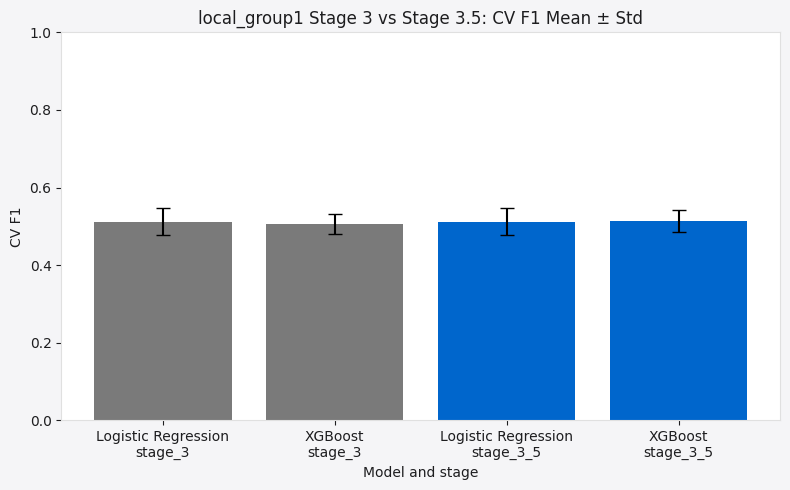

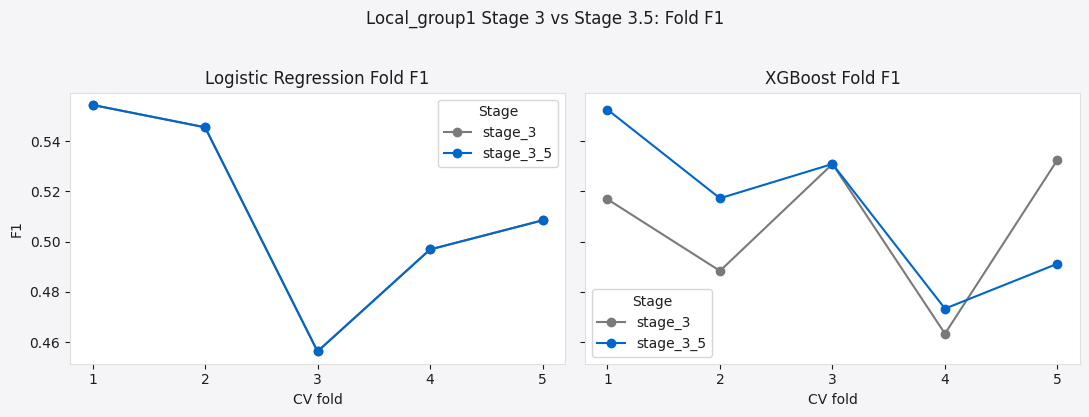

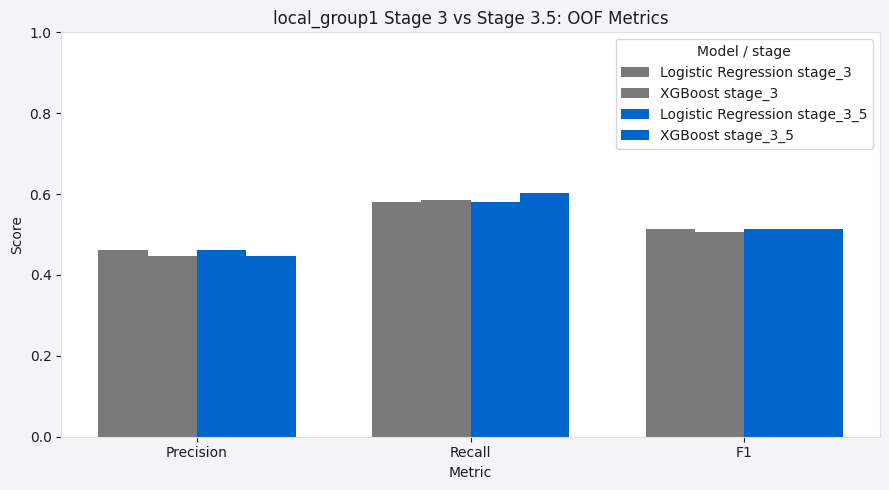

In [14]:
# 1. Stage 3 vs Stage 3.5 CV F1 mean ± std
fig, ax = plt.subplots(figsize=(8, 5))
plot_data = final_summary.copy()
labels = [f"{LABELS[row.model]}\n{row.stage}" for row in plot_data.itertuples()]
ax.bar(labels, plot_data['cv_f1_mean'], yerr=plot_data['cv_f1_std'], capsize=5, color=[COLORS[stage] for stage in plot_data['stage']])
ax.set_title('local_group1 Stage 3 vs Stage 3.5: CV F1 Mean ± Std') # 제목 수정
ax.set_xlabel('Model and stage')
ax.set_ylabel('CV F1')
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

# 2. 모델별 5개 fold F1
fold_data = json.loads(artifact_paths['final_fold_f1'].read_text(encoding='utf-8'))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, model_name in zip(axes, ('logistic_regression', 'xgboost')):
    for stage, color in (('stage_3', COLORS['stage_3']), ('stage_3_5', COLORS['stage_3_5'])):
        ax.plot(range(1, 6), fold_data[stage][model_name], marker='o', label=stage, color=color)
    ax.set_title(f"{LABELS[model_name]} Fold F1")
    ax.set_xlabel('CV fold')
    ax.set_xticks(range(1, 6))
    ax.legend(title='Stage')
axes[0].set_ylabel('F1')
fig.suptitle('Local_group1 Stage 3 vs Stage 3.5: Fold F1', y=1.03) # 제목 수정
plt.tight_layout(); plt.show()

# 3. Stage별 OOF Precision / Recall / F1
metrics = ['oof_precision', 'oof_recall', 'oof_f1']
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(metrics)); width = 0.18
for offset, row in enumerate(final_summary.itertuples()):
    values = [getattr(row, metric) for metric in metrics]
    ax.bar(x + (offset - 1.5) * width, values, width, label=f"{LABELS[row.model]} {row.stage}", color=COLORS[row.stage])
ax.set_title('local_group1 Stage 3 vs Stage 3.5: OOF Metrics') # 제목 수정
ax.set_xlabel('Metric'); ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.set_xticks(x, ['Precision', 'Recall', 'F1'])
ax.legend(title='Model / stage')
plt.tight_layout(); plt.show()

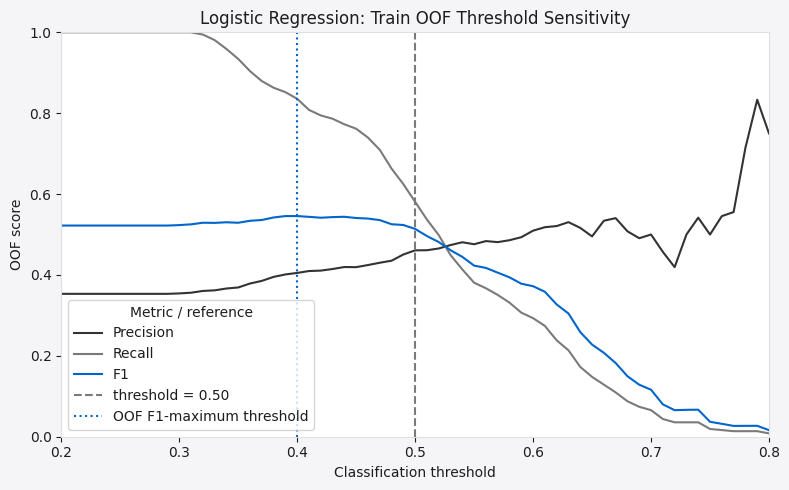

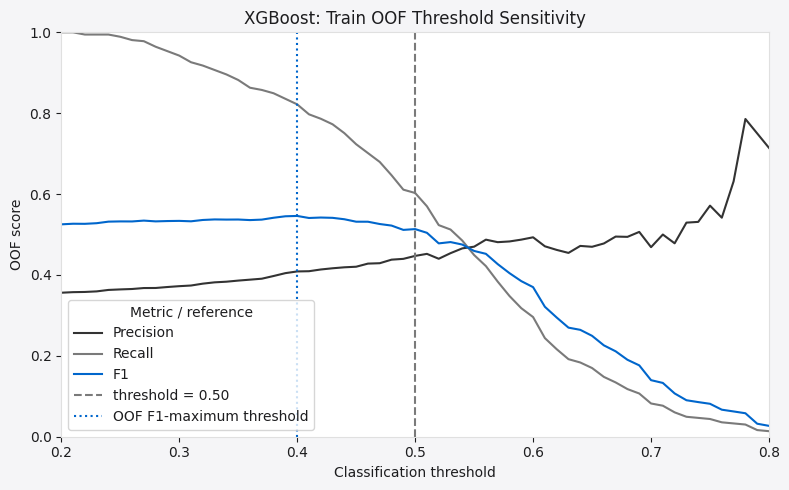

,model,stage,feature_count,cv_f1_mean,cv_f1_std,oof_precision,oof_recall,oof_f1,oof_roc_auc,best_params,stage_3_cv_f1_mean,stage_3_oof_f1,delta_cv_f1_from_stage_3,delta_oof_f1_from_stage_3
2,logistic_regression,stage_3_5,25,0.512309,0.035346,0.460870,0.580822,0.513939,0.633084,"{'C': 0.1, 'class_weight': 'balanced', 'penalt...",0.512309,0.513939,0.000000,0.00000
3,xgboost,stage_3_5,25,0.513039,0.028073,0.447154,0.602740,0.513419,0.626319,"{'subsample': 1.0, 'colsample_bytree': 0.8, 's...",0.506410,0.506509,0.006629,0.00691


In [15]:
# 4~5. refined OOF threshold sensitivity. 표시선은 참고용이며 threshold를 바꾸지 않는다.
for model_name in ('logistic_regression', 'xgboost'):
    data = threshold_sensitivity.query('model == @model_name')
    selected = threshold_summary.query('model == @model_name').set_index('threshold_type')
    fig, ax = plt.subplots(figsize=(8, 5))
    for metric, color in [('precision', '#333333'), ('recall', '#7a7a7a'), ('f1', '#0066cc')]:
        ax.plot(data['threshold'], data[metric], label=metric.title(), color=color)
    ax.axvline(0.5, color='#7a7a7a', linestyle='--', label='threshold = 0.50')
    ax.axvline(selected.loc['oof_best', 'threshold'], color='#0066cc', linestyle=':', label='OOF F1-maximum threshold')
    ax.set_title(f"{LABELS[model_name]}: Train OOF Threshold Sensitivity")
    ax.set_xlabel('Classification threshold')
    ax.set_ylabel('OOF score')
    ax.set_xlim(0.20, 0.80); ax.set_ylim(0, 1)
    ax.legend(title='Metric / reference')
    plt.tight_layout(); plt.show()

# 사람이 Stage 4 후보와 threshold 정책을 판단할 수 있도록 수치만 제공한다.
comparison = final_summary.merge(
    final_summary.query("stage == 'stage_3'")[['model', 'cv_f1_mean', 'oof_f1']].rename(columns={'cv_f1_mean': 'stage_3_cv_f1_mean', 'oof_f1': 'stage_3_oof_f1'}),
    on='model', how='left'
)
comparison['delta_cv_f1_from_stage_3'] = comparison['cv_f1_mean'] - comparison['stage_3_cv_f1_mean']
comparison['delta_oof_f1_from_stage_3'] = comparison['oof_f1'] - comparison['stage_3_oof_f1']
display(comparison[comparison['stage'] == 'stage_3_5'])